# Step 1 — Analysis units

Spec: `CLAUDE.md` §6, step 1.

- Units are 250 m cells (California Albers, EPSG:3310, grid origin 0,0) in Monterey (06053) and
  Santa Cruz (06087) with **≥ 60 % CDL class 221 (Strawberries) in both 2022 and 2023**.
- Cells touching permanent water (JRC GSW `occurrence` > 50) are excluded. "Touching" is
  implemented as: the cell contains or partly overlaps at least one 30 m GSW pixel with
  occurrence > 50.
- A cell is assigned to a county by its centroid (Earth Engine samples cells whose centre is in
  either county).
- For comparison only (not a scope change), the notebook also counts cells that would qualify
  on 2023 alone, because CDL 2022 maps far less strawberry area than CDL 2023.

Outputs in `data/derived/`: `01_candidate_cells.geojson` (cache of every cell ≥ 60 % in either
year), `01_units_polygons.geojson`, `01_units_centroids.csv`, `01_units_map.html` (interactive
check map). Figure: `figures/fig1_study_area.png`.

Existing derived files are never overwritten; delete a file to regenerate it.

**CHECKPOINT:** the human confirms the units are strawberry fields, not greenhouses, nurseries,
or misclassified lettuce.

In [1]:
import ee
import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import box

import common as C
from maps import HALO, add_north_arrow, add_scale_bar, s2_basemap

ee.Initialize(project=C.EE_PROJECT)
C.DERIVED.mkdir(parents=True, exist_ok=True)
C.FIGURES.mkdir(parents=True, exist_ok=True)
print("Earth Engine project:", C.EE_PROJECT)

Earth Engine project: cropczyk


## Study area

In [2]:
counties_fc = ee.FeatureCollection(C.COUNTIES).filter(ee.Filter.inList("GEOID", C.COUNTY_GEOIDS))
region = counties_fc.geometry()
counties = gpd.GeoDataFrame.from_features(counties_fc.getInfo()["features"], crs="EPSG:4326")
counties = counties[["GEOID", "NAME", "geometry"]].sort_values("GEOID").reset_index(drop=True)
counties_m = counties.to_crs(C.GRID_CRS)
print(counties[["GEOID", "NAME"]].to_string(index=False))
print("dataset:", C.COUNTIES)

GEOID       NAME
06053   Monterey
06087 Santa Cruz
dataset: TIGER/2018/Counties


## Strawberry fraction and permanent water on the 250 m grid

In [3]:
grid = ee.Projection(C.GRID_CRS, [C.CELL_M, 0, 0, 0, -C.CELL_M, 0])


def cdl(year):
    col = ee.ImageCollection(C.CDL).filterDate(f"{year}-01-01", f"{year + 1}-01-01")
    n = col.size().getInfo()
    assert n == 1, f"expected 1 CDL image for {year}, found {n}"
    return col.first().select("cropland")


def strawberry_fraction(year):
    img = cdl(year)
    return (img.eq(C.CDL_STRAWBERRY).unmask(0).setDefaultProjection(img.projection())
            .reduceResolution(ee.Reducer.mean(), maxPixels=1024)
            .reproject(grid).rename(f"frac_{year}"))


gsw = ee.Image(C.GSW).select("occurrence")
perm_water = (gsw.unmask(0).gt(C.PERMANENT_WATER).setDefaultProjection(gsw.projection())
              .reduceResolution(ee.Reducer.max(), maxPixels=1024)
              .reproject(grid).rename("perm_water"))
print("datasets:", C.CDL, "(band cropland, class", C.CDL_STRAWBERRY, ")", "|", C.GSW)

datasets: USDA/NASS/CDL (band cropland, class 221 ) | JRC/GSW1_4/GlobalSurfaceWater


## Candidate cells (≥ 60 % strawberry in either year), cached

In [4]:
CAND = C.DERIVED / "01_candidate_cells.geojson"


def cell_boxes(cols, rows):
    s = C.CELL_M
    return [box(c * s, -(r + 1) * s, (c + 1) * s, -r * s) for c, r in zip(cols, rows)]


if CAND.exists():
    cand = gpd.read_file(CAND)
    print(f"Loaded cached {CAND.name} (delete it to recompute)")
else:
    f22, f23 = strawberry_fraction(2022), strawberry_fraction(2023)
    keep = f22.gte(C.MIN_STRAWBERRY_FRAC).Or(f23.gte(C.MIN_STRAWBERRY_FRAC))
    stack = f22.addBands(f23).addBands(perm_water).updateMask(keep)
    fc = stack.sample(region=region, projection=grid, geometries=True, dropNulls=True, tileScale=4)
    n = fc.size().getInfo()
    assert n < 5000, f"{n} cells is too many for getInfo; switch to an ee.batch export"
    pts = gpd.GeoDataFrame.from_features(fc.getInfo()["features"], crs="EPSG:4326").to_crs(C.GRID_CRS)

    # Sample points are pixel centres; snap them to integer grid indices.
    cand = pd.DataFrame({
        "col": np.floor(pts.geometry.x / C.CELL_M).astype(int),
        "row": np.floor(-pts.geometry.y / C.CELL_M).astype(int),
        "frac_2022": pts["frac_2022"], "frac_2023": pts["frac_2023"],
        "perm_water": pts["perm_water"].astype(int),
    })
    cand["x_3310"] = cand.col * C.CELL_M + C.CELL_M / 2
    cand["y_3310"] = -(cand.row * C.CELL_M + C.CELL_M / 2)
    cand.insert(0, "unit_id", [f"c{c}_r{r}" for c, r in zip(cand.col, cand.row)])
    assert cand.unit_id.is_unique

    cent = gpd.GeoDataFrame(cand[["unit_id"]], crs=C.GRID_CRS,
                            geometry=gpd.points_from_xy(cand.x_3310, cand.y_3310))
    joined = gpd.sjoin(cent, counties_m, how="left", predicate="within")
    joined = joined[~joined.index.duplicated()]
    cand["county_geoid"], cand["county"] = joined["GEOID"].values, joined["NAME"].values
    ll = cent.to_crs("EPSG:4326").geometry
    cand["lon"], cand["lat"] = ll.x.round(6).values, ll.y.round(6).values

    cand = gpd.GeoDataFrame(cand, geometry=cell_boxes(cand.col, cand.row), crs=C.GRID_CRS)
    cand = cand.sort_values(["row", "col"]).reset_index(drop=True)
    cand.to_crs("EPSG:4326").to_file(CAND, driver="GeoJSON")
    print(f"Wrote {CAND.name}")

# Rebuild exact cell squares in EPSG:3310 from the grid indices.
cand = gpd.GeoDataFrame(cand.drop(columns="geometry"), crs=C.GRID_CRS,
                        geometry=cell_boxes(cand.col, cand.row))

MIN = C.MIN_STRAWBERRY_FRAC
cand["water"] = cand.perm_water > 0
cand["keep_spec"] = (cand.frac_2022 >= MIN) & (cand.frac_2023 >= MIN) & ~cand.water
cand["keep_2023_only"] = (cand.frac_2023 >= MIN) & ~cand.water
units = cand[cand.keep_spec].copy()
print("candidate cells:", len(cand), "| units (spec rule):", len(units))

Loaded cached 01_candidate_cells.geojson (delete it to recompute)
candidate cells: 129 | units (spec rule): 15


## Unit counts

In [5]:
both = (cand.frac_2022 >= MIN) & (cand.frac_2023 >= MIN)
summary = pd.DataFrame({
    "cells": [
        int((cand.frac_2022 >= MIN).sum()),
        int((cand.frac_2023 >= MIN).sum()),
        int(both.sum()),
        int((both & cand.water).sum()),
        int(cand.keep_spec.sum()),
        int(cand.keep_2023_only.sum()),
    ]
}, index=[
    "≥ 60 % strawberry in 2022",
    "≥ 60 % strawberry in 2023",
    "≥ 60 % in both years",
    "  of which touch permanent water (excluded)",
    "UNITS (spec: both years, no water)",
    "comparison: 2023 only, no water",
])
print(summary.to_string())
print()
by_county = pd.DataFrame({
    "units (spec)": cand[cand.keep_spec].groupby("county").size(),
    "2023-only rule": cand[cand.keep_2023_only].groupby("county").size(),
}).fillna(0).astype(int)
print(by_county.to_string())
print()
print(f"n units = {len(units)} | date window: CDL crop years 2022 and 2023 | "
      f"datasets: {C.CDL} (class {C.CDL_STRAWBERRY}), {C.GSW} (occurrence > {C.PERMANENT_WATER}), {C.COUNTIES}")

                                             cells
≥ 60 % strawberry in 2022                       17
≥ 60 % strawberry in 2023                      127
≥ 60 % in both years                            15
  of which touch permanent water (excluded)      0
UNITS (spec: both years, no water)              15
comparison: 2023 only, no water                127

            units (spec)  2023-only rule
county                                  
Monterey               8              80
Santa Cruz             7              47

n units = 15 | date window: CDL crop years 2022 and 2023 | datasets: USDA/NASS/CDL (class 221), JRC/GSW1_4/GlobalSurfaceWater (occurrence > 50), TIGER/2018/Counties


## Why does CDL 2022 map so much less strawberry than 2023?

Diagnostic only, not part of the unit rule. At 30 m in both counties: what CDL 2022 called the
pixels CDL 2023 calls Strawberries, and the reverse.

In [6]:
first = ee.ImageCollection(C.CDL).filterDate("2023-01-01", "2024-01-01").first()
class_names = dict(zip(
    [int(v) for v in first.get("cropland_class_values").getInfo().split(",")],
    first.get("cropland_class_names").getInfo().split(","),
))


def cross_classes(src_year, where_year, top=8):
    hist = (cdl(src_year).updateMask(cdl(where_year).eq(C.CDL_STRAWBERRY))
            .reduceRegion(ee.Reducer.frequencyHistogram(), region, maxPixels=1e10, tileScale=4)
            .get("cropland").getInfo())
    df = pd.DataFrame({"class": [int(float(k)) for k in hist], "pixels": list(hist.values())})
    df["name"] = df["class"].map(class_names)
    df["ha"] = (df.pixels * 900 / 1e4).round(0).astype(int)
    df["share"] = (df.pixels / df.pixels.sum()).map("{:.1%}".format)
    return df.sort_values("pixels", ascending=False).head(top)[["class", "name", "pixels", "ha", "share"]]


print("CDL 2022 class of pixels that CDL 2023 labels Strawberries:")
print(cross_classes(2022, 2023).to_string(index=False))
print("\nCDL 2023 class of pixels that CDL 2022 labels Strawberries:")
print(cross_classes(2023, 2022).to_string(index=False))
print(f"\nn units = {len(units)} | date window: CDL crop years 2022 and 2023 | dataset: {C.CDL}")

CDL 2022 class of pixels that CDL 2023 labels Strawberries:


 class                 name       pixels   ha share
   152            Shrubland 16322.819608 1469 31.9%
   221         Strawberries 13855.152941 1247 27.1%
   176        Grass/Pasture  8335.000000  750 16.3%
    36              Alfalfa  3412.772549  307  6.7%
    61 Fallow/Idle Cropland  1828.000000  165  3.6%
   111           Open Water  1466.000000  132  2.9%
   195  Herbaceous Wetlands  1026.000000   92  2.0%
    12           Sweet Corn   573.000000   52  1.1%

CDL 2023 class of pixels that CDL 2022 labels Strawberries:


 class                  name       pixels   ha share
   221          Strawberries 13855.152941 1247 90.5%
   152             Shrubland   978.000000   88  6.4%
   195   Herbaceous Wetlands   200.000000   18  1.3%
   176         Grass/Pasture    87.000000    8  0.6%
   142      Evergreen Forest    46.000000    4  0.3%
    37 Other Hay/Non Alfalfa    32.000000    3  0.2%
   131                Barren    28.000000    3  0.2%
   111            Open Water    26.000000    2  0.2%

n units = 15 | date window: CDL crop years 2022 and 2023 | dataset: USDA/NASS/CDL


## Save units (never overwrites)

In [7]:
POLY = C.DERIVED / "01_units_polygons.geojson"
CENT = C.DERIVED / "01_units_centroids.csv"
cols = ["unit_id", "county_geoid", "county", "col", "row", "x_3310", "y_3310",
        "lon", "lat", "frac_2022", "frac_2023"]

for path, write in [
    (POLY, lambda p: units[cols + ["geometry"]].to_crs("EPSG:4326").to_file(p, driver="GeoJSON")),
    (CENT, lambda p: units[cols].to_csv(p, index=False)),
]:
    if path.exists():
        print(f"{path.name} exists; not overwritten (delete it to regenerate)")
    else:
        write(path)
        print(f"Wrote {path.name}")
print(f"n units = {len(units)}")

01_units_polygons.geojson exists; not overwritten (delete it to regenerate)
01_units_centroids.csv exists; not overwritten (delete it to regenerate)
n units = 15


## Figure 1 — study area and units (checkpoint map)

Basemap: Sentinel-2 true-colour median, Aug–Sep 2023, from scenes with < 10 % cloud, then
masked with Cloud Score+ (cached GeoTIFFs in `data/derived/`, not committed). A longer window
exceeds Earth Engine's interactive memory limit. Town positions are approximate reference
coordinates, not survey data. The Pajaro River line is not drawn yet: no river dataset is
listed in §5.

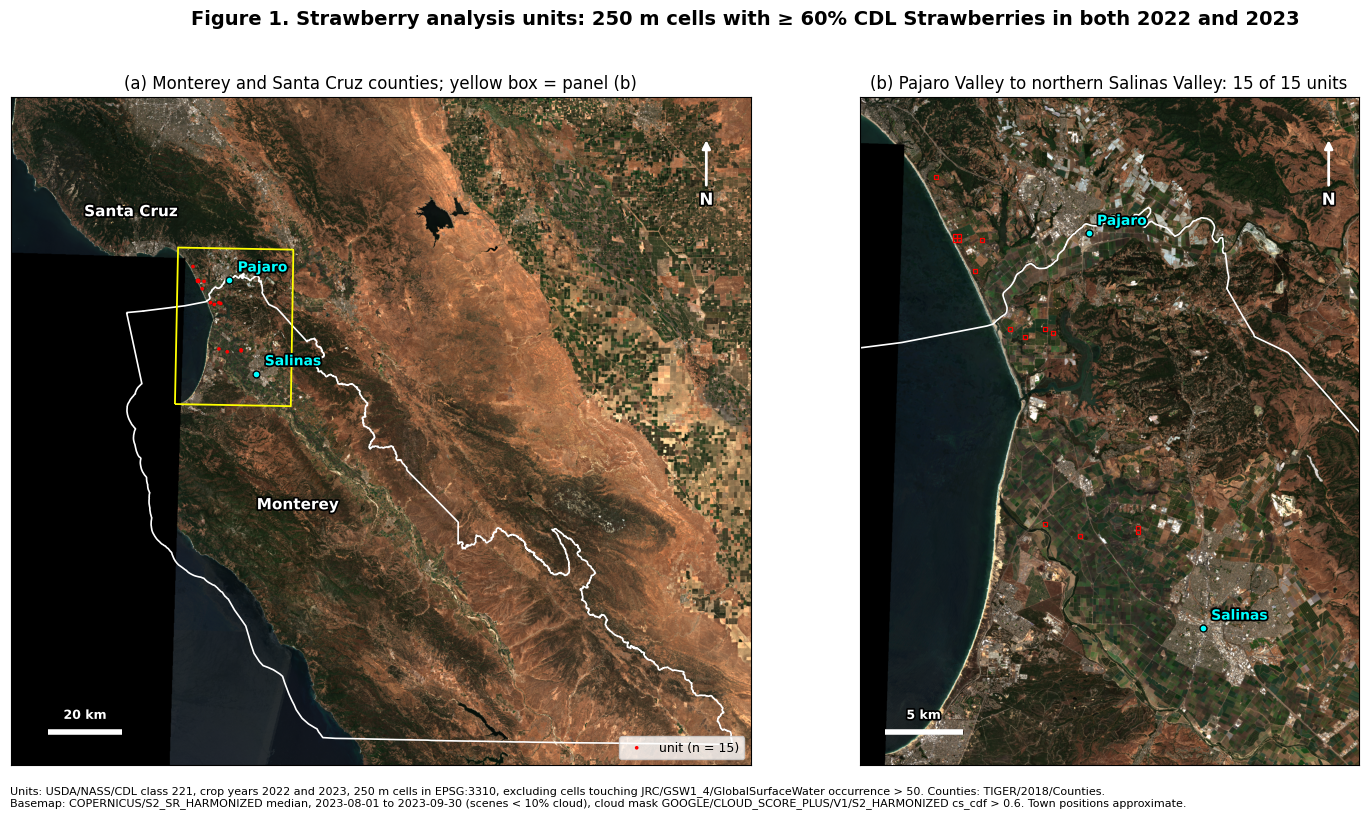

Saved fig1_study_area.png | n units = 15 (15 in zoom panel) | date window: CDL 2022 and 2023; basemap 2023-08-01 to 2023-09-30 (scenes < 10% cloud) | datasets: USDA/NASS/CDL, JRC/GSW1_4/GlobalSurfaceWater, TIGER/2018/Counties, COPERNICUS/S2_SR_HARMONIZED, GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED


In [8]:
OVERVIEW_LL = tuple(np.round(counties.total_bounds + np.array([-0.05, -0.05, 0.05, 0.05]), 3))
ZOOM_LL = (-121.90, 36.60, -121.55, 36.98)    # Pajaro Valley to northern Salinas Valley
BASEMAP_WINDOW = ("2023-08-01", "2023-10-01")  # Aug 1 – Sep 30, 2023
BASEMAP_LABEL = "2023-08-01 to 2023-09-30 (scenes < 10% cloud)"

ov_rgb, ov_ext = s2_basemap(C.DERIVED / "01_basemap_overview.tif", OVERVIEW_LL, 120, *BASEMAP_WINDOW)
zm_rgb, zm_ext = s2_basemap(C.DERIVED / "01_basemap_zoom.tif", ZOOM_LL, 20, *BASEMAP_WINDOW)

TOWNS = {"Pajaro": (-121.7427, 36.9041), "Salinas": (-121.6555, 36.6777)}  # approximate
towns = gpd.GeoDataFrame({"name": list(TOWNS)}, crs="EPSG:4326",
                         geometry=gpd.points_from_xy(*zip(*TOWNS.values()))).to_crs(C.GRID_CRS)
zoom_box = gpd.GeoSeries([box(*ZOOM_LL)], crs="EPSG:4326").to_crs(C.GRID_CRS)
in_zoom = units.centroid.within(zoom_box.iloc[0])

fig, (a, b) = plt.subplots(1, 2, figsize=(15, 8.2))
for ax, rgb, ext in [(a, ov_rgb, ov_ext), (b, zm_rgb, zm_ext)]:
    ax.imshow(rgb, extent=ext, origin="upper")
    counties_m.boundary.plot(ax=ax, color="white", lw=1.2)
    for _, t in towns.iterrows():
        ax.plot(t.geometry.x, t.geometry.y, marker="o", ms=5, color="cyan", mec="black")
        ax.annotate(t["name"], (t.geometry.x, t.geometry.y), xytext=(6, 6), textcoords="offset points",
                    color="cyan", fontsize=10, fontweight="bold", path_effects=HALO)
    ax.set_xlim(ext[0], ext[1])
    ax.set_ylim(ext[2], ext[3])
    ax.set_xticks([])
    ax.set_yticks([])

a.scatter(units.x_3310, units.y_3310, s=7, c="red", edgecolors="none", label=f"unit (n = {len(units)})")
zoom_box.boundary.plot(ax=a, color="yellow", lw=1.3)
for _, c in counties_m.iterrows():
    p = c.geometry.representative_point()
    a.annotate(c["NAME"], (p.x, p.y), color="white", fontsize=11, fontweight="bold",
               ha="center", path_effects=HALO)
a.legend(loc="lower right", fontsize=9)
a.set_title("(a) Monterey and Santa Cruz counties; yellow box = panel (b)")

units[in_zoom].boundary.plot(ax=b, color="red", lw=0.9)
b.set_title(f"(b) Pajaro Valley to northern Salinas Valley: {int(in_zoom.sum())} of {len(units)} units")

add_scale_bar(a, 20)
add_scale_bar(b, 5)
add_north_arrow(a)
add_north_arrow(b)

fig.suptitle("Figure 1. Strawberry analysis units: 250 m cells with ≥ 60% CDL Strawberries "
             "in both 2022 and 2023", fontsize=14, fontweight="bold")
fig.text(0.01, 0.005,
         f"Units: {C.CDL} class {C.CDL_STRAWBERRY}, crop years 2022 and 2023, 250 m cells in EPSG:3310, "
         f"excluding cells touching {C.GSW} occurrence > {C.PERMANENT_WATER}. Counties: {C.COUNTIES}.\n"
         f"Basemap: {C.S2} median, {BASEMAP_LABEL}, cloud mask {C.S2_CLOUD} cs_cdf > {C.CLEAR_CS_CDF}. "
         "Town positions approximate.",
         fontsize=8, va="bottom")
fig.tight_layout(rect=(0, 0.04, 1, 0.96))
FIG1 = C.FIGURES / "fig1_study_area.png"
fig.savefig(FIG1, dpi=200)
plt.show()
print(f"Saved {FIG1.name} | n units = {len(units)} ({int(in_zoom.sum())} in zoom panel) | "
      f"date window: CDL 2022 and 2023; basemap {BASEMAP_LABEL} | "
      f"datasets: {C.CDL}, {C.GSW}, {C.COUNTIES}, {C.S2}, {C.S2_CLOUD}")

## Interactive check map

High-resolution Esri World Imagery for checking units against greenhouses, nurseries and
lettuce. The layer of cells that qualify on 2023 alone is off by default (layer control, top right).

In [9]:
MAP = C.DERIVED / "01_units_map.html"
if MAP.exists():
    print(f"{MAP.name} exists; not overwritten (delete it to regenerate)")
else:
    tip_cols = ["unit_id", "county", "frac_2022", "frac_2023"]

    def layer(df, name, color, show=True):
        d = df[tip_cols + ["geometry"]].round({"frac_2022": 2, "frac_2023": 2}).to_crs("EPSG:4326")
        return folium.GeoJson(d, name=name, show=show,
                              style_function=lambda _: {"color": color, "weight": 1.5, "fillOpacity": 0.1},
                              tooltip=folium.GeoJsonTooltip(fields=tip_cols))

    m = folium.Map(location=[36.80, -121.72], zoom_start=11, tiles=None, control_scale=True)
    folium.TileLayer("Esri.WorldImagery", name="Esri World Imagery").add_to(m)
    folium.GeoJson(counties, name="Counties",
                   style_function=lambda _: {"color": "white", "weight": 2, "fill": False}).add_to(m)
    layer(cand[cand.keep_2023_only & ~cand.keep_spec], "Qualify on 2023 only (comparison)",
          "yellow", show=False).add_to(m)
    layer(units, f"Units, spec rule (n = {len(units)})", "red").add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)
    m.save(MAP)
    print(f"Wrote {MAP.name}")
print(f"n units = {len(units)} | date window: CDL 2022 and 2023 | datasets: {C.CDL}, {C.GSW}, {C.COUNTIES}")

Wrote 01_units_map.html
n units = 15 | date window: CDL 2022 and 2023 | datasets: USDA/NASS/CDL, JRC/GSW1_4/GlobalSurfaceWater, TIGER/2018/Counties
